- In the notebook section we use the `src/data/synthetic/generate/*.parquet` files, kept separate from the `src/` code.
- Since the FTTL system is meant to out-perform the call handler (who does not have engineer knowledge), it is assumed acceptable to train on the **garage engineer's verified-outcome rows** only.

# Build 03 — Mitigating the SFP Loop by Reweighting

**Goal.** The live model (v2) is retrained on the v1 production log. Cars the model *scraps* are
recorded as `total_loss = 1` **without ever going to a garage** — a *forced* label. Retraining on
those forced labels teaches v2 to over-predict total loss, which scraps more cars, which produces
more forced labels: the self-fulfilling prophecy (SFP) loop.

**Idea.** Keep the data, but change how much each row is *trusted* during retraining. A
`sample_weight` on XGBoost **is** a reweighting: rows with a genuine, garage-verified outcome keep
full weight; rows whose label was *forced* by a scrap decision are trusted less.

### The three kinds of rows (vocabulary from Bekker & Davis 2020, "PU learning", p28)

> A word of caution on **"scrapped"**: a car can also be scrapped *after* a garage confirms a total
> loss. Below, **model-scrapped** means the model fast-tracked it to scrap with **no garage visit** —
> the label was forced, never checked. Only that group is contaminated.

| Group | Definition | Label trustworthy? |
|---|---|---|
| **P — verified total loss** | went to garage (`model_v1_decision = 0`) and outcome `= 1` | ✅ engineer-verified |
| **N — verified repairable** | went to garage (`model_v1_decision = 0`) and outcome `= 0` | ✅ engineer-verified |
| **U — forced positive** | **model-scrapped** (`model_v1_decision = 1`), label forced to 1, no garage | ❌ unknown — the SFP lives here |

Only **P** and **N** carry a real answer. **U** is the problem.

### Where each row sits — the score × decision grid

|  | **garage** (real label) | **model-scrapped** (forced = 1, no garage) |
|---|---|---|
| **high score (≥ τ)** | ① rare, verified — GOLD | ② contaminated (U) — the SFP core |
| **low score (< τ)** | ③ common repairable  ·  ④ rare true total loss | — (low scores are never scrapped) |

- **② high score + model-scrapped** — labels all forced to 1. This *is* the SFP: the cell where the
  loop feeds on itself.
- **① high score + garage** — rare but pure gold: the only *verified* signal in the high-score region
  (cars that scored high yet were still sent to a garage).
- **③ / ④ low score + garage** — the ordinary verified rows: mostly repairable (③), with a rare
  genuine total loss (④).

> **Reality check (run Step 0):** in this log the grid is split almost perfectly by the threshold —
> cell ① holds **≈ 0 rows**, because v1's decision is a near-deterministic cutoff. That empty corner
> *is* the positivity gap: the high-score region has essentially **no verified signal**, which is
> exactly why the model-scrapped labels there cannot be checked.

### Why not plain inverse-propensity weighting (IPW)?

This notebook was first sketched as *"using inverse propensity score"*. That does **not** work here.
The scrap decision is a near-deterministic score threshold — Build 02 measured propensity-to-scrap
**AUC = 0.998**. So the probability of being scrapped is ≈ 0 or ≈ 1, never in between: there is **no
overlap** between the model-scrapped and garage regions at a given score (a *positivity violation*).
IPW divides by that probability, so in the scrapped region the weights blow up. We therefore reweight
with a **trust factor**, not an inverse propensity.

### The reweighting plan — two independent axes

- **Axis B — discount the contaminated cell ②** *(the SFP-specific fix)*: give model-scrapped rows a
  weight below 1, reflecting how likely they were *actually* total losses.
- **Axis A — protect the rare verified signal ①④** *(optional, complementary)*: up-weight the rare
  garage-verified rows near τ so the model still learns the true edge inside the contaminated region.
  *(Caveat: when cell ① is empty — as it is here — Axis A has almost nothing to act on at high scores,
  so **Axis B is the main lever**. Axis A mostly helps cell ④, the rare low-score total losses.)*

### Logic this notebook runs (this pass builds the diagnostic foundation)

1. **Load** the v1 log; split rows into P / N / U and print the grid counts.
2. **True total-loss rate (Step 1)** — from the documented pre-model figures (15% scrapped, 43%
   fast-tracked) get a sharp band for the true rate (best ≈ 15%). This is the *external anchor*.
3. **Model over-scrapping (Step 1b + Step 2)** — is the model's scrap rate above that anchor, and of
   the cars it scrapped, how many were really total losses (via `g(x)` fit on verified rows)?
4. **Read the clues together (Step 3)** — a scrap rate at/above the anchor *plus* a low really-TL
   share among scrapped cars = over-scrapping = the loop.

> Reweighting + XGBoost retrain (using these numbers) is the **next** step, built on this diagnostic.

### Step 0 — Load the v1 production log and split into P / N / U

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "data" / "synthetic" / "run.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PARQUET = ROOT / "src" / "data" / "synthetic" / "generate" / "parquet"

log = pd.read_parquet(PARQUET / "claims_v1_log.parquet")   # 2022–2024, the v1 production log

# What actually happened under v1 -------------------------------------------------
scrapped = log["model_v1_decision"] == 1        # model-scrapped: fast-tracked, NO garage (unverified)
garage   = log["model_v1_decision"] == 0        # went to garage -> real outcome observed
outcome  = log["model_v1_observed_outcome"]     # for garage rows this is the true result

P = garage & (outcome == 1)                     # verified total loss
N = garage & (outcome == 0)                     # verified repairable
U = scrapped                                    # contaminated forced positives (model-scrapped)

print(f"P  verified total loss : {int(P.sum()):>6,}")
print(f"N  verified repairable : {int(N.sum()):>6,}")
print(f"U  model-scrapped (forced 1) : {int(U.sum()):>6,}   ({U.mean():.1%} of all rows)")

# score × decision grid (τ = 0.872) ----------------------------------------------
TAU  = 0.872
high = log["model_v1_score"] >= TAU
grid = pd.crosstab(
    pd.Series(np.where(high, "high score (>=τ)", "low score (<τ)"), name="score"),
    pd.Series(np.where(scrapped, "model-scrapped", "garage"), name="decision"),
)
print("\nscore × decision grid:\n", grid)

# Feature matrix reused by Steps 2+ (one-hot encode the categoricals) -------------
FEATURES = [
    "vehicle_age_years", "mileage", "driver_age", "prior_claims_count", "customer_tenure_years",
    "repair_to_value_ratio", "vehicle_value", "repair_estimate_gbp", "report_delay_days",
    "used_car_price_index", "is_weekend_claim", "has_prior_claims", "is_high_value_vehicle",
    "car_driveable", "vehicle_make", "vehicle_model", "vehicle_type", "damage_type",
    "damage_location", "damage_severity", "agent_channel", "coverage_type",
]
X = pd.get_dummies(log[FEATURES], drop_first=True).astype(float)

P  verified total loss :  1,023
N  verified repairable : 18,771
U  model-scrapped (forced 1) :  3,431   (14.8% of all rows)

score × decision grid:
 decision          garage  model-scrapped
score                                   
high score (>=τ)       0            3413
low score (<τ)     19794              18


### Step 1 — What was the true total-loss rate *before any model*? (the anchor)

Before any model (rules + handler judgement), the documented figures are:
- **15%** of all cars were scrapped (called total loss);
- of those, **43%** were *fast-tracked* — scrapped on handler judgement with **no garage visit**
  (label forced, never verified); the other **57%** went to a garage and were confirmed total losses.

As shares of **all** cars:

| group | share of all cars | truth known? |
|---|---|---|
| garage → repairable | **85.00%** | ✅ verified non-TL |
| garage → total loss | **8.55%** | ✅ verified TL |
| fast-track, no garage | **6.45%** | ❌ unverified |

So **93.55% of cars have a verified outcome; only 6.45% are in doubt.**

The **true total-loss rate** (the *class prior*) is therefore:
- **≥ 8.55%** — the verified total losses alone;
- **≤ 15%** — if every fast-tracked car really was a total loss;
- **best estimate ≈ 15%** — fast-track rules fired only on *obvious* total losses (e.g. rollover),
  so almost all of that 6.45% really were total losses.

This is a **sharp bound**: the 93.55% verified part adds no uncertainty; only the small 6.45% does.

**Why it matters:** before any model, scrap rate (15%) ≈ true rate (~15%) → scrapping was
**well-calibrated**. If a model's scrap rate climbs *above* ~15%, the excess is over-scrapping —
the SFP signature.

In [2]:
PRE_ML_SCRAP_RATE     = 0.15   # config.py — 15% of pre-model cars were scrapped (called total loss)
PRE_ML_FASTTRACK_FRAC = 0.43   # config.py — of those, 43% fast-tracked (no garage, unverified)

garage_repairable    = 1 - PRE_ML_SCRAP_RATE                             # 85.00%  verified non-TL
garage_confirmed_TL  = PRE_ML_SCRAP_RATE * (1 - PRE_ML_FASTTRACK_FRAC)   #  8.55%  verified TL
fast_track_no_garage = PRE_ML_SCRAP_RATE *      PRE_ML_FASTTRACK_FRAC    #  6.45%  unverified
verified_share       = garage_repairable + garage_confirmed_TL          # 93.55%  verified in total

true_TL_rate_min  = garage_confirmed_TL     # 8.55% : if NONE of the fast-tracked were really TL
true_TL_rate_max  = PRE_ML_SCRAP_RATE       # 15%   : if ALL  of the fast-tracked were really TL
true_TL_rate_best = PRE_ML_SCRAP_RATE       # ~15%  : fast-track = obvious TL -> near the top

print(f"verified non-TL (garage)         : {garage_repairable:>7.2%}")
print(f"verified total loss (garage)     : {garage_confirmed_TL:>7.2%}")
print(f"unverified fast-track (no garage) : {fast_track_no_garage:>7.2%}")
print(f"verified in total                 : {verified_share:>7.2%}")
print()
print(f"TRUE total-loss rate (class prior): {true_TL_rate_min:.2%} to {true_TL_rate_max:.2%}, best ~ {true_TL_rate_best:.0%}")

verified non-TL (garage)         :  85.00%
verified total loss (garage)     :   8.55%
unverified fast-track (no garage) :   6.45%
verified in total                 :  93.55%

TRUE total-loss rate (class prior): 8.55% to 15.00%, best ~ 15%


### Step 1b — Does the model scrap *more often* than the true rate?

Compare each model's scrap rate against the ~15% anchor; anything clearly above ~15% is
over-scrapping.

> **On the threshold.** τ = 0.872 is **v1's** cutoff. In production each *new* version re-tunes its
> own threshold to hold **precision ≥ 0.985** (a false positive = a repairable car scrapped = a direct
> loss), so a single shared τ is only a rough *rate-inflation symptom* — it mixes policy with each
> model's score scale. Below we read the stored v1/v2a scores at τ = 0.872 as a quick symptom check;
> the **operating-point** comparison (each version at its own precision-0.985 threshold, read
> out-of-time) is done properly in the **Cascade re-evaluation** section at the end. There, holding
> precision is the *binding* constraint and the sharper signal — together with Step 2 (how many of the
> scrapped cars were really total losses).

In [3]:
for v in ["v1", "v2a"]:
    rate = (log[f"model_{v}_score"] >= TAU).mean()      # scrap rate at the τ = 0.872 cutoff
    flag = "over-scrapping" if rate > true_TL_rate_best + 0.005 else "≈ anchor"
    print(f"model {v:3s} scrap rate : {rate:6.1%}   (anchor ~ {true_TL_rate_best:.0%})   {flag}")

model v1  scrap rate :  14.7%   (anchor ~ 15%)   ≈ anchor
model v2a scrap rate :  15.4%   (anchor ~ 15%)   ≈ anchor


### Step 2 — Of the cars the *model* scrapped, how many were really total losses?

Same question as the anchor, now for the model. Our unverified group is **model-scrapped**
(`model_v1_decision = 1`): fast-tracked with no garage, so never checked.

*Transport* = train where we have real answers, then carry it over to where we don't:

1. Fit `g(x) = P(total loss | features)` on **garage** cars (verified — both outcomes present).
2. Score every **model-scrapped** car → *"how likely was this really a total loss?"*
3. Average → the share of model-scrapped cars that were really total losses.

**Benchmark:** pre-model fast-track fired only on *obvious* total losses, so its true-TL rate was
near **100%**. A model number well below that means the model is scrapping cars that were *not*
clearly total losses — false-positive scrapping.

> Model-scrapped cars sit in a high-score region garage cars barely cover, so this is only an
> approximation (it tends to *under*-state the true share). Trust the **direction** and the
> **version-to-version trajectory** more than the exact level.

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier

# 'garage' / 'scrapped' come from Step 0.  scrapped == model-scrapped (no garage, unverified).
g = HistGradientBoostingClassifier(random_state=42)
g.fit(X[garage], outcome[garage].astype(int))                    # fit on the verified (garage) cars

share_really_TL = g.predict_proba(X[scrapped])[:, 1].mean()      # average over model-scrapped cars
print(f"share of MODEL-scrapped cars that were really total losses ~ {share_really_TL:.1%}")
print(f"false-positive scrapping rate                              ~ {1 - share_really_TL:.1%}")
print(f"(pre-model fast-track benchmark was near 100%)")

share of MODEL-scrapped cars that were really total losses ~ 55.3%
false-positive scrapping rate                              ~ 44.7%
(pre-model fast-track benchmark was near 100%)


### Step 3 — Read the two clues together

- **Before the model:** scrap rate 15% ≈ true rate ~15% → calibrated; fast-track ≈ obvious TL
  (~100% correct).
- **With the model:** the scrap rate (Step 1b) and the really-TL share among scrapped cars (Step 2).

To the extent the model scraps at/above the true rate while a chunk of those scrapped cars were *not*
really total losses, the model is over-scrapping repairable cars → the SFP loop. (The level is only
partially identified — read the trajectory across versions, not the absolute number.)

In [5]:
v1_scrap = (log["model_v1_score"] >= TAU).mean()
print(f"pre-model true TL rate (anchor)   : ~{true_TL_rate_best:.0%}")
print(f"model v1 scrap rate               : {v1_scrap:.1%}")
print(f"really-TL share among scrapped    : ~{share_really_TL:.0%}   (benchmark ~100%)")
print(f"=> ~{1 - share_really_TL:.0%} of model-scrapped cars look repairable -> false-positive scrapping")

pre-model true TL rate (anchor)   : ~15%
model v1 scrap rate               : 14.7%
really-TL share among scrapped    : ~55%   (benchmark ~100%)
=> ~45% of model-scrapped cars look repairable -> false-positive scrapping


## Implementation — reweight and retrain v2

We now retrain v2 (XGBoost on the v1 log) under four schemes and compare them:

| scheme | garage rows (P, N) | model-scrapped rows (U) |
|---|---|---|
| **naive** (baseline) | weight 1, real label | **weight 1, forced label 1** ← the SFP |
| **Axis B** (soft split, method *c*) | weight 1, real label | **split**: weight `g(x)` as total-loss + weight `1−g(x)` as repairable |
| **Axis A** (rarity) | weight = rarity of its cell | weight = rarity of its cell, forced label 1 |
| **A + B** | rarity × 1 | rarity × the Axis-B split |

**Split (temporal, honest evaluation).** Train on **2022-01 → 2024-04**; hold out **OOT 2024-05 →
2024-10**. All metrics are read on the OOT slice, and discrimination is scored only on OOT **garage**
rows (the ones with a verified label).

### Setup — split, transport model `g`, and a training helper

In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

dates      = pd.to_datetime(log["claim_date"])
train_mask = (dates >= "2022-01-01") & (dates <= "2024-04-30")   # v2 training window
oot_mask   = (dates >= "2024-05-01") & (dates <= "2024-10-31")   # OOT holdout (evaluation only)

label = log["model_v1_observed_outcome"].astype("int64")         # v2's target (forced to 1 for U)
hi    = (log["model_v1_score"] >= TAU).astype(int)               # score region: 1 = high (>=τ)

# Transport model for the per-row split — fit on garage∩train only (no OOT leakage).
g_tr = HistGradientBoostingClassifier(random_state=42)
g_tr.fit(X[garage & train_mask], label[garage & train_mask])

def fit_xgb(X_tr, y_tr, w_tr):
    m = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
    m.fit(X_tr, y_tr, sample_weight=w_tr)
    return m

# Baseline: naive v2 — every row weight 1, model-scrapped rows keep their forced label 1.
clf_naive = fit_xgb(X[train_mask], label[train_mask], np.ones(int(train_mask.sum())))
print(f"train rows: {int(train_mask.sum()):,}   OOT rows: {int(oot_mask.sum()):,}")

train rows: 17,900   OOT rows: 4,051


### Axis B — per-row soft split of the forced positives (method *c*)

Each model-scrapped row is not trusted as a clean positive. Instead we **split it in two**, using the
transport score `g(x) = P(total loss | features)`:

- a total-loss example with weight `g(x)`,
- a repairable example with weight `1 − g(x)`.

A scrapped car that *looks* repairable (`g(x)` low) then contributes mostly as a **negative**; one
that looks like a genuine total loss stays mostly positive. This is the version that actually uses
the per-row transport value (a constant weight would throw that information away).

In [7]:
g_rows = train_mask & garage
u_rows = train_mask & scrapped
gu = g_tr.predict_proba(X[u_rows])[:, 1]          # P(true TL | features) for each model-scrapped row

# garage rows: real label, weight 1.  model-scrapped rows: duplicated and split by gu.
X_B = pd.concat([X[g_rows], X[u_rows], X[u_rows]])
y_B = np.concatenate([label[g_rows].to_numpy(), np.ones(len(gu)),  np.zeros(len(gu))])
w_B = np.concatenate([np.ones(int(g_rows.sum())), gu,              1 - gu])

clf_B = fit_xgb(X_B, y_B, w_B)
print(f"Axis B rows (garage + split scrapped): {len(y_B):,}   mean g(x) over U = {gu.mean():.3f}")

Axis B rows (garage + split scrapped): 20,388   mean g(x) over U = 0.562


### Axis A — rarity reweighting  *(your idea)*

Weight each row by how **rare** its `(score region × label)` cell is: rare, informative cells up,
common cells down. Cells (code `= 2·score_high + label`):

- `0` repairable · low score — very common → **down**
- `1` total loss · low score (④) — rare, verified → **up**
- `2` repairable · high score (①) — ≈ empty here (positivity gap)
- `3` total loss · high score (②, the forced U) — the contaminated cell

> **Can Axis A stand alone as a mitigation? No.** It never touches the forced label in cell ②, and
> the positive class is *dominated* by those forced U rows (more U than verified P). Up-weighting
> "rare positives" therefore risks **amplifying** the contamination — watch the scrap rate go the
> wrong way below. Axis A only becomes safe once Axis B has already discounted U; then it protects
> the rare *verified* signal (mostly cell ④).

In [8]:
code = (hi * 2 + label).astype(int)                       # cell id per row
freq = code[train_mask].value_counts(normalize=True)     # cell frequencies on the train window
mult = (1.0 / (freq.size * freq)).clip(0.25, 4.0)         # inverse-frequency, capped
mult = mult / mult.mean()                                 # normalise to mean 1

w_A = code[train_mask].map(mult).to_numpy()
clf_A = fit_xgb(X[train_mask], label[train_mask], w_A)

names = {0: "repairable·low", 1: "totalloss·low (④)", 2: "repairable·high (①)", 3: "totalloss·high (②U)"}
print("rarity multiplier per cell:")
for c in sorted(mult.index):
    print(f"  {names.get(c, c):22s}  x{mult[c]:.2f}")

rarity multiplier per cell:
  repairable·low          x0.18
  totalloss·low (④)       x1.76
  totalloss·high (②U)     x1.06


### Combined — Axis A rarity × Axis B soft split

Multiply the two: keep Axis B's soft split of U, and scale every row by its Axis-A rarity multiplier.
The model-scrapped rows all sit in cell ② (`code = 3`), so their split weights are scaled by that one
multiplier. When the rarity multipliers are all 1 this collapses back to pure Axis B.

In [9]:
wg  = code[g_rows].map(mult).to_numpy()          # garage rows: rarity of their own cell
m_u = float(mult.get(3, 1.0))                     # model-scrapped rows all live in cell ② (code 3)

X_AB = pd.concat([X[g_rows], X[u_rows], X[u_rows]])
y_AB = np.concatenate([label[g_rows].to_numpy(), np.ones(len(gu)), np.zeros(len(gu))])
w_AB = np.concatenate([wg,                        gu * m_u,        (1 - gu) * m_u])

clf_AB = fit_xgb(X_AB, y_AB, w_AB)
print(f"Combined rows: {len(y_AB):,}   cell-② multiplier applied to U = {m_u:.2f}")

Combined rows: 20,388   cell-② multiplier applied to U = 1.06


### Compare — naive vs A vs B vs A+B on the OOT holdout

In [10]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

def evaluate(clf, name):
    og    = oot_mask & garage
    s     = clf.predict_proba(X[oot_mask])[:, 1]
    s_og  = clf.predict_proba(X[og])[:, 1]
    y_og  = label[og]
    pred  = (s_og >= TAU).astype(int)                             # scrap decision at τ on verified rows
    tn, fp, fn, tp = confusion_matrix(y_og, pred, labels=[0, 1]).ravel()
    return {
        "model": name,
        "OOT scrap rate": float((s >= TAU).mean()),               # SFP symptom: over-scrapping
        "OOT mean score": float(s.mean()),                        # score-drift proxy
        "OOT garage AUC": float(roc_auc_score(y_og, s_og)),       # discrimination (threshold-free)
        "precision": float(precision_score(y_og, pred, zero_division=0)),   # target >= 0.985
        "recall":    float(recall_score(y_og, pred, zero_division=0)),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),         # confusion matrix @ τ
    }

results = pd.DataFrame([
    evaluate(clf_naive, "naive v2 (baseline)"),
    evaluate(clf_A,     "Axis A only"),
    evaluate(clf_B,     "Axis B only (soft split)"),
    evaluate(clf_AB,    "Axis A + B combined"),
]).set_index("model")
print("confusion matrix on OOT garage rows at τ=0.872:  FP = repairable car scrapped (costly), TP = true TL scrapped")
results.round(4)

confusion matrix on OOT garage rows at τ=0.872:  FP = repairable car scrapped (costly), TP = true TL scrapped


,OOT scrap rate,OOT mean score,OOT garage AUC,precision,recall,TN,FP,FN,TP
model,,,,,,,,,
naive v2 (baseline),0.1851,0.2244,0.7559,0.5833,0.0819,3135,10,157,14
Axis A only,0.1980,0.2875,0.7653,0.4143,0.1696,3104,41,142,29
Axis B only (soft split),0.0106,0.1402,0.7557,1.0000,0.0117,3145,0,169,2
Axis A + B combined,0.0121,0.2030,0.7517,0.4667,0.0409,3137,8,164,7


### Reading the results (seed = 42)

- **Axis A only pushes the scrap rate *up*.** This is the standalone-mitigation failure made
  concrete: rebalancing toward the rare positive class amplifies the forced U rows, so v2 scraps
  *more*. AUC may edge up (better ranking) but the SFP symptom worsens — A alone is not a fix.
- **Axis B collapses the scrap rate with AUC essentially unchanged.** Discounting the forced
  positives removes the over-prediction without hurting discrimination. But the collapse is *very*
  strong — the **over-correction / recall-collapse risk** (the same failure mode that shelved v3).
  Putting a **floor** under the per-row weight (so `g(x)` can't drive the positive weight to ≈ 0) is
  the natural knob, so the scrap rate lands near the ~15% anchor instead of collapsing.
- **A + B** keeps B's correction while A restores some positive sensitivity — a middle ground, and
  the one place Axis A finally does useful, *safe* work.

### Further work

- Tune the Axis-B split (floor the per-row weight / calibrate the resulting scrap rate to the ~15%
  anchor from Step 1) so it corrects without collapsing.
- Recompute the **really-TL share among scrapped cars** (Step 2) on each retrained model's scrapped
  set, and compare the trajectory against the pre-model ~100% fast-track benchmark.
- Add calibration (ECE) on OOT garage rows and a PSI score-drift panel vs v1.

## Cascade re-evaluation — does each scheme survive being propagated (at the real operating point)?

The table above compares the four schemes at **one** generation (v2) and at a **fixed** τ = 0.872.
Two things are missing:

1. **The loop is a cascade** — v2's scrap decisions become v3's training labels. A fix that looks good
   at v2 can degenerate when propagated, so we run each scheme **one generation further**.
2. **The real policy is not a fixed τ.** τ = 0.872 is *v1's* cutoff; every version re-tunes its
   threshold to hold **precision ≥ 0.985** (a false positive = a repairable car scrapped = a direct
   loss). Comparing schemes at one shared τ mixes policy with each model's score scale — so here each
   version **deploys at its own precision-0.985 threshold**, tuned on the verified **train garage**
   rows, and we read what that operating point actually delivers **out-of-time**.

> **Cascade, not independent.** Each scheme's gen-2 decisions (at its tuned threshold) define gen-3's
> training data, exactly as the contamination propagates.
>
> **Oracle-free constraint.** Genuine labels exist only where the **real v1 production** garaged, so
> gen-3's garage pool is `(v1 garage) ∧ (gen-2 garage)`; rows a scheme newly garages have no
> observable label here and are dropped.

We read, over `v1 → gen-2 → gen-3`: the threshold-free **ψ_t = f_t(0)** loop signal, and — at each
version's **deployable precision-0.985 threshold** — the **OOT precision** (does it survive out-of-time?),
**recall**, and **scrap rate** vs the ~15% anchor. The generator's deployed `v1 → v2a → v3a` is the
faint reference.

In [11]:
import sys
sys.path.insert(0, str(ROOT / "src"))                 # make the detector package importable
import matplotlib.pyplot as plt
from detector.algorithm.residual_peak import peak0, residual, classification_metrics
from detector.report import plot_metric_trajectory

og   = oot_mask & garage                          # common OOT garage set (only verified labels)
gtr  = train_mask & garage                        # verified garage rows in the training window
gen2 = {"naive": clf_naive, "A": clf_A, "B": clf_B, "AB": clf_AB}

# The real policy is NOT a fixed τ: each version re-tunes its threshold to hold precision >= 0.985.
TARGET_PREC = 0.985
gtr_y, gtr_pos = label[gtr].to_numpy(), int((label[gtr] == 1).sum())
og_y,  og_pos  = label[og].to_numpy(),  int((label[og] == 1).sum())

def tune_precision(scores, y, npos, target=TARGET_PREC):
    """Smallest-score operating point holding precision >= target, chosen to max recall.
    Returns (thr, precision, recall, n_scrapped) or None if the target is infeasible."""
    best = None
    for t in np.unique(scores):
        pred = scores >= t; n = int(pred.sum())
        if n == 0:
            continue
        prec = float(y[pred].mean())
        if prec >= target:
            rec = float((pred & (y == 1)).sum() / max(npos, 1))
            if best is None or rec > best[2]:
                best = (float(t), prec, rec, n)
    return best

def deploy_thr(scores_on_gtr):
    """Deployable threshold: hold precision >= 0.985 on TRAIN garage (the data available at
    deployment time), maximising recall. Falls back to the v1 cutoff τ if infeasible in-sample."""
    t = tune_precision(scores_on_gtr, gtr_y, gtr_pos)
    return (t[0], True) if t else (TAU, False)

def rarity(cells):
    f = cells[train_mask].value_counts(normalize=True); m = (1.0 / (f.size * f)).clip(0.25, 4.0)
    return m / m.mean()

def cascade_gen3(clf2, scheme):
    """gen-3 trained on gen-2's log. Crucially, gen-2 SCRAPS at its own DEPLOYABLE
    (precision-0.985-tuned) threshold — not the fixed v1 τ — so the cascade propagates each
    version's real operating point. Oracle-free -> gen-3 garage pool = (v1 garage) & (gen-2 garage)."""
    score2  = clf2.predict_proba(X)[:, 1]
    thr2, _ = deploy_thr(clf2.predict_proba(X[gtr])[:, 1])          # gen-2's precision-0.985 threshold
    scrap2  = pd.Series(score2 >= thr2, index=log.index)           # decision at the tuned threshold
    label2  = pd.Series(np.where(scrap2.values, 1, label.values), index=log.index)
    hi2     = scrap2.astype(int)
    g_rows2 = train_mask & garage & (~scrap2)
    u_rows2 = train_mask & scrap2
    if scheme in ("naive", "A"):
        y = label2[train_mask].to_numpy(); code2 = (hi2 * 2 + label2).astype(int)
        w = (np.ones(int(train_mask.sum())) if scheme == "naive"
             else code2[train_mask].map(rarity(code2)).to_numpy())
        return fit_xgb(X[train_mask], y, w)
    gu2 = g_tr.predict_proba(X[u_rows2])[:, 1]
    Xc  = pd.concat([X[g_rows2], X[u_rows2], X[u_rows2]])
    yc  = np.concatenate([label[g_rows2].to_numpy(), np.ones(len(gu2)), np.zeros(len(gu2))])
    if scheme == "B":
        wc = np.concatenate([np.ones(int(g_rows2.sum())), gu2, 1 - gu2])
    else:
        code2 = (hi2 * 2 + label2).astype(int); m2 = rarity(code2); mu2 = float(m2.get(3, 1.0))
        wc = np.concatenate([code2[g_rows2].map(m2).to_numpy(), gu2 * mu2, (1 - gu2) * mu2])
    return fit_xgb(Xc, yc, wc)

gen3 = {k: cascade_gen3(v, k) for k, v in gen2.items()}
print("gen-3 cascade built (gen-2 scraps at its own precision-0.985 threshold):", list(gen3))

gen-3 cascade built (gen-2 scraps at its own precision-0.985 threshold): ['naive', 'A', 'B', 'AB']


In [12]:
# Two readings per model (via the shared detector library):
#   ψ = peak0(residual) — residual-peak loop signal, threshold-free, unchanged by tuning
#   the OPERATING POINT under precision>=0.985 — deploy at the precision-tuned threshold, then read
#   OOT AUC / precision / recall / confusion matrix / scrap (what you actually GET out-of-time).
def operating_point(clf):
    thr, feas = deploy_thr(clf.predict_proba(X[gtr])[:, 1])
    s_og, s_oot = clf.predict_proba(X[og])[:, 1], clf.predict_proba(X[oot_mask])[:, 1]
    cm = classification_metrics(og_y, s_og, thr)          # AUC/precision/recall/CM @ deploy thr
    return {
        "ψ loop":         round(peak0(residual(og_y, s_og)), 3),
        "deploy thr":     round(thr, 3),
        "feasible@train": feas,
        "OOT AUC":        round(cm["AUC"], 3),            # threshold-free discrimination
        "OOT precision":  round(cm["precision"], 3),      # target 0.985
        "OOT recall":     round(cm["recall"], 3),
        "TN": cm["TN"], "FP": cm["FP"], "FN": cm["FN"], "TP": cm["TP"],   # FP = repairable scrapped
        "scrap@thr":      round(float((s_oot >= thr).mean()), 3),
        "scrap@τ=0.872":  round(float((s_oot >= TAU).mean()), 3),         # fixed-τ contrast
    }

cascade_tbl = pd.DataFrame({f"{k}·g2": operating_point(gen2[k]) for k in gen2}
                           | {f"{k}·g3": operating_point(gen3[k]) for k in gen2}).T
print(f"precision target = {TARGET_PREC};  OOT garage = {og_pos} true TL / {len(og_y)} rows;  anchor scrap ~15%")
print("deploy thr tuned on TRAIN garage (in-sample precision held); AUC/precision/recall/CM read OUT-OF-TIME.")
print("confusion matrix: FP = repairable car scrapped (costly), TP = true total loss correctly scrapped.\n")
cascade_tbl

precision target = 0.985;  OOT garage = 171 true TL / 3316 rows;  anchor scrap ~15%
deploy thr tuned on TRAIN garage (in-sample precision held); AUC/precision/recall/CM read OUT-OF-TIME.
confusion matrix: FP = repairable car scrapped (costly), TP = true total loss correctly scrapped.



,ψ loop,deploy thr,feasible@train,OOT AUC,OOT precision,OOT recall,TN,FP,FN,TP,scrap@thr,scrap@τ=0.872
naive·g2,7.112,0.358,True,0.756,0.376,0.292,3062,83,121,50,0.214,0.185
A·g2,4.455,0.977,True,0.765,0.571,0.07,3136,9,159,12,0.184,0.198
B·g2,7.229,0.418,True,0.756,0.36,0.181,3090,55,140,31,0.163,0.011
AB·g2,4.471,0.867,True,0.752,0.467,0.041,3137,8,164,7,0.012,0.012
naive·g3,6.886,0.997,True,0.763,0.5,0.006,3144,1,170,1,0.174,0.186
A·g3,4.593,0.947,True,0.752,0.529,0.105,3129,16,153,18,0.187,0.196
B·g3,8.318,0.715,True,0.748,0.5,0.018,3142,3,168,3,0.044,0.01
AB·g3,5.601,0.628,True,0.738,0.371,0.076,3123,22,158,13,0.167,0.067


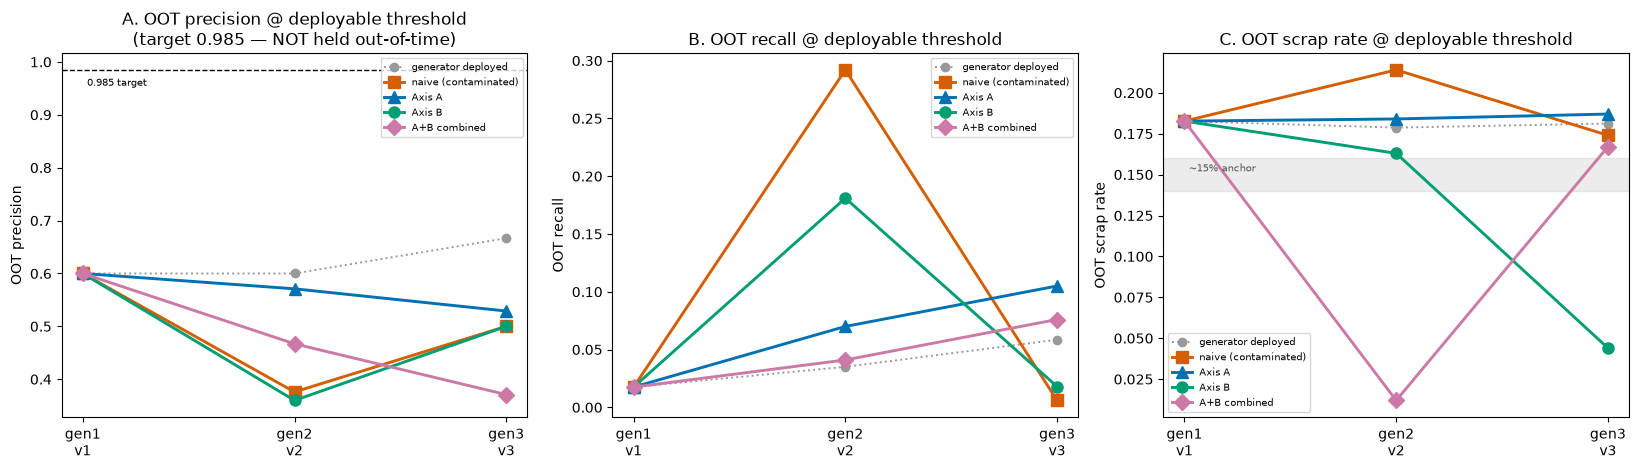

In [ ]:
# ---- Figure: the OPERATING POINT under precision>=0.985, per scheme, v1 -> gen2 -> gen3 ----
# Trajectories drawn by detector.report.plot_metric_trajectory; panel choice / target lines here.
COL = {"naive": "#D55E00", "A": "#0072B2", "B": "#009E73", "AB": "#CC79A7"}   # Okabe-Ito, fixed order
MK  = {"naive": "s", "A": "^", "B": "o", "AB": "D"}
LBL = {"naive": "naive (contaminated)", "A": "Axis A", "B": "Axis B", "AB": "A+B combined"}
xt  = ["gen1\nv1", "gen2\nv2", "gen3\nv3"]

def gen_point(col):                               # generator reference: tune on train garage, read OOT
    thr, _ = deploy_thr(log.loc[gtr, col].values)
    pred = log.loc[og, col].values >= thr
    prec = float(og_y[pred].mean()) if pred.sum() else np.nan
    rec  = float((pred & (og_y == 1)).sum() / og_pos)
    scrap = float((log.loc[oot_mask, col].values >= thr).mean())
    return prec, rec, scrap

def mod_point(clf):
    r = operating_point(clf)
    return r["OOT precision"], r["OOT recall"], r["scrap@thr"]

gref = [gen_point(c) for c in ["model_v1_score", "model_v2a_score", "model_v3a_score"]]
v1pt = gref[0]                                     # shared v1 anchor

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))
panels = [(0, "A. OOT precision @ deployable threshold\n(target 0.985 — NOT held out-of-time)", "OOT precision"),
          (1, "B. OOT recall @ deployable threshold", "OOT recall"),
          (2, "C. OOT scrap rate @ deployable threshold", "OOT scrap rate")]
for gi, title, ylab in panels:
    series = {"generator deployed": [gref[0][gi], gref[1][gi], gref[2][gi]]}
    styles = {"generator deployed": {"color": "#999999", "ls": ":", "marker": "o", "ms": 6, "lw": 1.4}}
    for k in gen2:
        p2, p3 = mod_point(gen2[k]), mod_point(gen3[k])
        series[LBL[k]] = [v1pt[gi], p2[gi], p3[gi]]
        styles[LBL[k]] = {"color": COL[k], "marker": MK[k], "ms": 8, "lw": 2.1}
    plot_metric_trajectory(series, ax=ax[gi], xticklabels=xt, ylabel=ylab, title=title, styles=styles,
                           hline=(TARGET_PREC, {}) if gi == 0 else None,
                           band=(0.14, 0.16, {}) if gi == 2 else None)
    ax[gi].legend(fontsize=7)
ax[0].text(0.02, TARGET_PREC - 0.03, "0.985 target", fontsize=7)
ax[2].text(0.02, 0.152, "~15% anchor", fontsize=7, color="#555")
plt.tight_layout()
plt.show()

### Reading the cascade re-evaluation (at the real precision ≥ 0.985 operating point)

Once each version is deployed at its **precision-0.985 threshold** (tuned on train garage) instead of
a fixed τ, the comparison changes completely — and the honest result is a **negative** one.

- **The precision constraint is not held out-of-time — by any scheme (Panel A).** Every model holds
  precision ≥ 0.985 *in-sample* (on train garage, by construction) yet delivers only **≈ 0.37–0.53**
  OOT precision; even the deployed generator lands at ≈ 0.60–0.67. The threshold that looks safe on the
  tiny verified garage slice does not generalise — a pure **overfitting-of-the-verified-slice** gap.
  This is the quantitative face of the project's *precision-measured-against-contaminated-labels*
  caveat, and the reason v3 was shelved.
- **The fixed-τ trajectory was a threshold artifact.** At a common τ = 0.872 the schemes looked very
  different (naive/A over-scrap; B/AB collapse-then-recover). Re-tuning to the real operating point
  mostly erases that: scrap rates cluster near the anchor (Panel C) while **recall stays low**
  (Panel B) and precision fails uniformly. What looked like a scheme ranking was largely each model's
  score scale meeting a fixed cutoff.
- **ψ (residual peak) is threshold-free and unchanged** — it still reports the loop signal, but it
  cannot see the precision failure (its window is the low-score garage region). ψ is a *loop* signal,
  not an *operating-point* certificate: the precision/recall panels are what decide deployability.

**Takeaway.** On this contaminated, low-positivity garage slice, **reweighting alone cannot recover a
deployable precision ≥ 0.985 out-of-time** — the verified high-score region (cell ① ≈ empty) simply
has no signal to tune against, so any threshold that holds precision in-sample overfits. The route
forward is not a better weight but **breaking positivity**: obtaining verified labels in the
high-score region (e.g. auditing a random sample of would-be-scrapped cars), which is exactly the
randomisation strategy the later builds pursue.

> **Caveat.** Single-seed synthetic numbers on a 171-positive OOT garage slice — exact levels shift
> with seed/window, and tuning the threshold on so few verified positives is itself noisy. The
> transferable, qualitative result is the **train→OOT precision collapse** under the real constraint;
> re-check it on real Allianz data with a larger verified set.